# Notebook 02: Regression Model

**Student Name:** Erika Wooldridge

**Dataset:** The AI, ML, Data Science Salary (2020- 2025)

**Target Variable:** salary_in_usd

**Checkpoint 3 Due:** Feb 15

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before the checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll be asked to interpret results, justify decisions, and explain your reasoning. **These written reflections are a critical part of your grade.**

Good data scientists don't just run code—they communicate their findings clearly. Take time to write thoughtful, complete responses to all reflection prompts. This demonstrates your understanding and prepares you for real-world stakeholder communication.

---

## Setup

In [328]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Sklearn - models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier

# Sklearn - evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split, GridSearchCV

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Processed Data

In [329]:
# Load cleaned data from previous notebook
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (43090, 11)


,work_year,experience_level,salary_in_usd,remote_ratio,company_size,company_location_Other,company_location_US,job_title_Data Analyst,job_title_Machine Learning Engineer,job_title_Other,job_title_Software Engineer
0,2025,2,60000,50,2,1,0,0,0,1,0
1,2025,3,165000,0,1,0,1,0,0,1,0
2,2025,3,109000,0,1,0,1,0,0,1,0
3,2025,3,294000,0,1,0,1,0,0,1,0
4,2025,3,137600,0,1,0,1,0,0,1,0


In [330]:
# Define your target variable
TARGET = 'salary_in_usd'  # <-- UPDATE THIS!

print(f"Target: {TARGET}")
print(f"\nTarget statistics:")
print(df[TARGET].describe())

# Store target range for later interpretation
target_range = df[TARGET].max() - df[TARGET].min()
target_std = df[TARGET].std()
print(f"\nTarget range: {target_range:,.2f}")
print(f"Target std: {target_std:,.2f}")

Target: salary_in_usd

Target statistics:
count     43090.000000
mean     145190.028522
std       64825.717817
min       15000.000000
25%       95040.000000
50%      137400.000000
75%      186153.000000
max      333900.000000
Name: salary_in_usd, dtype: float64

Target range: 318,900.00
Target std: 64,825.72


## Section 2: Prepare Features and Target

In [331]:
# Separate features (X) and target (y)
X = df.drop(columns=[TARGET])
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nAll features ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (43090, 10)
Target shape: (43090,)

All features (10):
['work_year', 'experience_level', 'remote_ratio', 'company_size', 'company_location_Other', 'company_location_US', 'job_title_Data Analyst', 'job_title_Machine Learning Engineer', 'job_title_Other', 'job_title_Software Engineer']


In [332]:
# Check for any non-numeric columns that need to be handled
non_numeric = X.select_dtypes(include=['object', 'category']).columns.tolist()
if non_numeric:
    print(f"Warning: Non-numeric columns found: {non_numeric}")
    print("You need to encode these or go back to Notebook 01!")
else:
    print("All features are numeric. Ready to proceed!")

All features are numeric. Ready to proceed!


## Section 3: Train-Test Split

Split your data into training and test sets. The training set is used to train the model, and the test set is used to evaluate how well it generalizes to unseen data.

In [333]:
# TODO: Split your data into training and test sets
# 
# Requirements:
# - Use an 80/20 split (test_size=0.2)
# - Set random_state=42 for reproducibility
# - Store results in: X_train, X_test, y_train, y_test
#
# Hint: Use train_test_split(X, y, ...)

# Create feature matrix
# Create target variables
X = df.drop(columns=[TARGET])
y_data= df[TARGET]
print(f"Number of feature columns in X: {X.shape[1]}")
RANDOM_STATE = 42  # This is standard in industry!

X_train, X_test, y_train, y_test = train_test_split(
    X, y_data, test_size=0.2, random_state=RANDOM_STATE
)

print("Data split complete!")
print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")



Number of feature columns in X: 10
Data split complete!

Training samples: 34472
Testing samples: 8618


In [334]:
# Verify your split (run this cell to check)
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"X_train shape: {X_train.shape}")
print(f"X_train columns: {X_train.columns.tolist()}")


Training set: 34,472 samples (80%)
Test set: 8,618 samples (20%)
X_train shape: (34472, 10)
X_train columns: ['work_year', 'experience_level', 'remote_ratio', 'company_size', 'company_location_Other', 'company_location_US', 'job_title_Data Analyst', 'job_title_Machine Learning Engineer', 'job_title_Other', 'job_title_Software Engineer']


## Section 4: Feature Scaling

Many ML algorithms perform better when features are on similar scales. StandardScaler transforms features to have mean=0 and std=1.

**Important:** Fit the scaler on training data only, then transform both train and test. This prevents data leakage.

In [335]:
# Scale your features using StandardScaler

# 1. Create a StandardScaler instance
scaler = StandardScaler()

# 2. Fit the scaler on X_train and transform X_train (use fit_transform)
X_train_s = scaler.fit_transform(X_train)  # Fit on training data

# 3. Transform X_test using the same scaler (use transform only - NOT fit_transform!)
X_test_s= scaler.transform(X_test)       # Transform test data

# 4. Store results in: X_train_scaled, X_test_scaled
## Convert back to DataFrame for easier use
X_train_scaled = pd.DataFrame(X_train_s, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_s, columns=X_test.columns, index=X_test.index)
# Why fit only on train? To prevent "data leakage" - test data should be truly unseen.

print("Features scaled!")



Features scaled!


In [336]:
# Convert back to DataFrame for easier viewing (optional but helpful)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Verify scaling worked
print("Features scaled successfully!")
print(f"\nScaled feature means (should be ~0): {X_train_scaled.mean().mean():.4f}")
print(f"Scaled feature stds (should be ~1): {X_train_scaled.std().mean():.4f}")

Features scaled successfully!

Scaled feature means (should be ~0): -0.0000
Scaled feature stds (should be ~1): 1.0000


## Section 5: Baseline Model

Start with a simple Linear Regression to establish a baseline performance. This gives us a reference point for improvement.

In [337]:
# This helper function evaluates any model - you'll use it throughout this notebook
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train model and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    }
    
    return results, model, y_test_pred

In [338]:

# TODO: Create and evaluate a baseline Linear Regression model
#
# Steps:
# 1. Create a LinearRegression() model instance
model_linear = LinearRegression()

# 2. Use the evaluate_model() function to train and evaluate it
baseline_results, baseline_trained, baseline_preds = evaluate_model(
    model_linear,
    X_train_scaled,  # Your scaled training features
    X_test_scaled,   # Your scaled testing features
    y_train,            # Training targets
    y_test,             # Testing targets
    "Linear Regression Baseline"
)

# 3. Store the results
baseline_model = (baseline_results, baseline_trained, baseline_preds)

# The evaluate_model function returns: (results_dict, trained_model, predictions)
print(f"Baseline R2 Score: {baseline_results['Test R2']:.4f}")

Baseline R2 Score: 0.2420


In [339]:
# Display baseline results
print("=" * 50)
print("BASELINE MODEL: Linear Regression")
print("=" * 50)
print(f"Train R²: {baseline_results['Train R2']:.4f}")
print(f"Test R²:  {baseline_results['Test R2']:.4f}")
print(f"Test RMSE: {baseline_results['Test RMSE']:,.2f}")
print(f"Test MAE: {baseline_results['Test MAE']:,.2f}")

# Context for RMSE
print(f"\n--- RMSE in Context ---")
print(f"RMSE as % of target range: {baseline_results['Test RMSE']/target_range*100:.1f}%")
print(f"RMSE as % of target std: {baseline_results['Test RMSE']/target_std*100:.1f}%")

BASELINE MODEL: Linear Regression
Train R²: 0.2347
Test R²:  0.2420
Test RMSE: 56,667.09
Test MAE: 45,282.50

--- RMSE in Context ---
RMSE as % of target range: 17.8%
RMSE as % of target std: 87.4%


### Baseline Interpretation

*Analyze your baseline results:*

**Understanding your metrics:**
- **R² (0 to 1)**: How much variance in target is explained by features. 0.7+ is often considered good.
- **RMSE**: Average prediction error in the same units as your target. Lower is better.
- **RMSE as % of range**: Helps you understand if errors are big or small relative to your data.

**Questions to answer:**
- What does your R² score tell you about how well features explain the target? 
An R² score of 0.2391 indicates a weak-to-moderate correlation between the selected features and the target variable. The model accounts for about 24% of the variance in the salary. The remaining 76% of the features are not good predictors in the model. 


- Is there a big gap between train and test R²? (Gap > 0.1 could indicate overfitting)
The generalization gap remains well below the 0.1 threshold, demonstrating model stability and a lack of significant overfitting. This indicates that the model's learned coefficients are representative of the broader dataset.

- Is your RMSE reasonable? (e.g., if predicting house prices, is a $20K error acceptable?)
The RMSE of $57,603 is a large margin of error since it represents 88% of the standard deviation, The model's perdictions are nearly spread out as the data. If this data was used to decide exactly how much to pay someone, the data could lead to a massaive mistake.

**Your interpretation:**

The model is underfitting, meaning it is too simple to catch the real-world complexity of salaries. It’s like trying to guess someone's height using only their age—you’ll get a rough idea, but you’ll miss the mark most of the time. When a model underfits, it has high bias. It has made too many assumptions about the data and isn't flexible enough to see the nuances. This is why the $R^2$ is lower and the error is higher than we’d like for a professional tool.

## Section 6: Model Iteration

Try at least 2-3 different models to see if you can improve on the baseline.

In [340]:
# Store all results for comparison
all_results = [baseline_results]

# Dictionary to store trained models
trained_models = {
    'Linear Regression (Baseline)': baseline_trained
}

### Model 2: Ridge Regression

Ridge adds L2 regularization to prevent overfitting by penalizing large coefficients.

In [341]:
# TODO: Create and evaluate a Ridge Regression model
#
# Create a Ridge model with alpha=1.0
# Use evaluate_model() to train and evaluate
# Add results to all_results list
# Add trained model to trained_models dict

# Ridge Regression

ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train_scaled , y_train)

# Get the built-in scores
r2_ridge_train = ridge_model.score(X_train_scaled, y_train)
r2_ridge_test = ridge_model.score(X_test_scaled, y_test)

# GENERATE PREDICTIONS FIRST (This was the missing piece)
y_pred_Ridge = ridge_model.predict(X_test_scaled)

# Calculate metrics using predictions
from sklearn.metrics import r2_score, mean_squared_error
r2_Ridge = r2_score(y_test, y_pred_Ridge) 
rmse_Ridge = np.sqrt(mean_squared_error(y_test, y_pred_Ridge))

print("-" * 30)
print(f"{'Metric':<15} | {'Value':<10}")
print("-" * 30)
print(f"{'Train R²':<15} | {r2_ridge_train:.4f}")
print(f"{'Test R²':<15} | {r2_ridge_test:.4f}") # Fixed: was showing train score
print(f"{'R² Gap':<15} | {r2_ridge_train - r2_ridge_test:.4f}")
print(f"{'Test RMSE':<15} | {rmse_Ridge:.2f}")
print(f"{'Manual R²':<15} | {r2_Ridge:.4f}")
print("-" * 30)


------------------------------
Metric          | Value     
------------------------------
Train R²        | 0.2347
Test R²         | 0.2420
R² Gap          | -0.0072
Test RMSE       | 56667.11
Manual R²       | 0.2420
------------------------------


In [342]:
# Test a range of alphas on a logarithmic scale
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_cv = RidgeCV(alphas=alphas, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train)

print(f"Best Alpha: {ridge_cv.alpha_}")

Best Alpha: 10.0


### Model 3: Lasso Regression

Lasso adds L1 regularization, which can zero out unimportant features (automatic feature selection).

In [343]:
# TODO: Create and evaluate a Lasso Regression model
if not isinstance(all_results, dict):
    all_results = {}
if not isinstance(trained_models, dict):
    trained_models = {}

# Create a Lasso model with alpha=0.1
lasso_model = Lasso(alpha=1000)
lasso_model.fit(X_train_scaled, y_train)

# Use evaluate_model() to train and evaluate
lasso_results = {
    'Test R2': lasso_model.score(X_test_scaled, y_test),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, lasso_model.predict(X_test_scaled)))
}

# Add results to all_results and trained_models
lasso_trained = lasso_model
all_results['Lasso'] = lasso_results
trained_models['Lasso'] = lasso_trained

# Print results
print(f"Lasso Regression - Test R²: {lasso_results['Test R2']:.4f}, Test RMSE: {lasso_results['Test RMSE']:,.2f}")

# Show which features Lasso kept (non-zero coefficients)
lasso_coefs = pd.Series(lasso_trained.coef_, index=X.columns)
kept_features = lasso_coefs[lasso_coefs != 0]
print(f"\nLasso kept {len(kept_features)} of {len(X.columns)} features")

Lasso Regression - Test R²: 0.2402, Test RMSE: 56,733.13

Lasso kept 8 of 10 features


### ElasticNet (L1 + L2 Combined)

ElasticNet combines both penalties - it can zero out features AND shrink the rest.

In [344]:
#ElasticNet (L1 + L2 Combined)
elastic_model = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42)
elastic_model.fit(X_train_scaled, y_train)

r2_elastic_train = elastic_model.score(X_train_scaled, y_train)
r2_elastic_test = elastic_model.score(X_test_scaled, y_test)

print("ElasticNet (L1 + L2):")
print(f"  Train R²: {r2_elastic_train:.4f}")
print(f"  Test R²:  {r2_elastic_test:.4f}")
print(f"  Gap:      {r2_elastic_train - r2_elastic_test:.4f}")

ElasticNet (L1 + L2):
  Train R²: 0.2347
  Test R²:  0.2420
  Gap:      -0.0072


### PolynomialFeatures` transforms the data to capture curved relationships.

In [345]:
# 1. Initialize the transformer (degree 2 captures curves and interactions)
poly = PolynomialFeatures(degree=2, include_bias=False)

# 2. Transform the scaled data
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Original data:")
print(X_train_poly )
print("\nTransformed (degree 2):")
print(X_test_poly)
print("\nColumns are: [x, x²]")
print("\nFor x=2: [2, 4]")
print("For x=3: [3, 9]")

Original data:
[[-0.08827103 -0.64072995 -0.58383168 ...  0.28559708 -0.14188889
   0.07049252]
 [-0.08827103  0.71823411  1.72775688 ...  0.28559708 -0.14188889
   0.07049252]
 [-0.08827103  0.71823411 -0.58383168 ...  0.28559708 -0.14188889
   0.07049252]
 ...
 [-1.49051942 -0.64072995 -0.58383168 ...  0.28559708 -0.14188889
   0.07049252]
 [ 1.31397736  0.71823411 -0.58383168 ...  0.28559708 -0.14188889
   0.07049252]
 [-0.08827103  0.71823411 -0.58383168 ...  0.28559708 -0.14188889
   0.07049252]]

Transformed (degree 2):
[[-0.08827103  0.71823411 -0.58383168 ...  3.50143641  0.49681492
   0.07049252]
 [-0.08827103  0.71823411  1.72775688 ...  0.28559708 -0.14188889
   0.07049252]
 [-0.08827103 -0.64072995 -0.58383168 ...  0.28559708 -0.14188889
   0.07049252]
 ...
 [-0.08827103  2.07719817 -0.58383168 ...  0.28559708 -0.14188889
   0.07049252]
 [ 1.31397736 -1.99969401  1.72775688 ...  3.50143641  0.49681492
   0.07049252]
 [-0.08827103  0.71823411 -0.58383168 ...  0.28559708 -0.1

In [346]:
# Convert to DataFrame using the feature names generated by the poly object
poly_features = poly.get_feature_names_out(X_train_scaled.columns)

X_train_poly = pd.DataFrame(X_train_poly, columns=poly_features, index=X_train_scaled.index)
X_test_poly = pd.DataFrame(X_test_poly, columns=poly_features, index=X_test_scaled.index)

# Now look at the first few interaction features
print("New Polynomial Features include:")
print(X_train_poly.columns[10:20]) # This will show things like 'work_year^2' or 'work_year remote_ratio'

New Polynomial Features include:
Index(['work_year^2', 'work_year experience_level', 'work_year remote_ratio',
       'work_year company_size', 'work_year company_location_Other',
       'work_year company_location_US', 'work_year job_title_Data Analyst',
       'work_year job_title_Machine Learning Engineer',
       'work_year job_title_Other', 'work_year job_title_Software Engineer'],
      dtype='object')


In [347]:
# Create and evaluate Ridge on the Polynomial data
poly_ridge_model = Ridge(alpha=1.0)

# Use your evaluate_model function with the NEW poly DataFrames
poly_results, poly_trained, poly_preds = evaluate_model(
    poly_ridge_model, 
    X_train_poly, 
    X_test_poly, 
    y_train, 
    y_test, 
    "Polynomial Ridge (Degree 2)"
)

# Add to your results list
all_results["Polynomial Ridge"] = poly_results

print(f"Polynomial Ridge R²: {poly_results['Test R2']:.4f}")
print(f"Improvement over Baseline: {poly_results['Test R2'] - baseline_results['Test R2']:.4f}")

Polynomial Ridge R²: 0.2507
Improvement over Baseline: 0.0087


In [348]:
#ElasticNet (L1 + L2 Combined)
elastic_model = ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42)
elastic_model.fit(X_train_poly, y_train)

r2_elastic_train = elastic_model.score(X_train_poly, y_train)
r2_elastic_test = elastic_model.score(X_test_poly, y_test)

print("ElasticNet (L1 + L2):")
print(f"  Train R²: {r2_elastic_train:.4f}")
print(f"  Test R²:  {r2_elastic_test:.4f}")
print(f"  Gap:      {r2_elastic_train - r2_elastic_test:.4f}")

ElasticNet (L1 + L2):
  Train R²: 0.2421
  Test R²:  0.2507
  Gap:      -0.0086


### Model 4: Decision Tree

In [349]:
# TODO: Create and evaluate a Decision Tree model
#
# Create a DecisionTreeRegressor with max_depth=10 and random_state=42
tree_model = DecisionTreeRegressor(max_depth=7, random_state=42)
tree_model.fit(X_train, y_train) 

# Use evaluate_model() to train and evaluate
y_pred_tree = tree_model.predict(X_test)

r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
dt_results = {
    'Test R2': r2_tree,
    'Test RMSE': rmse_tree
}
# Print results
print(f"Decision Tree - Test R²: {dt_results['Test R2']:.4f}, Test RMSE: {dt_results['Test RMSE']:,.2f}")

Decision Tree - Test R²: 0.2502, Test RMSE: 56,358.70


In [350]:
# PAIR A: Task 3 - Hyperparameter Tuning
# Choose your best performing model and tune its hyperparameters

# Example for Decision Tree:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tree_for_tuning = DecisionTreeRegressor()
grid_search = GridSearchCV(
    estimator=tree_for_tuning,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1  # Use all CPU cores
)

print("Running GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)
print("Done!")


for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest Cross-Validation Score: {grid_search.best_score_:.4f}")

Running GridSearchCV...
Done!
  max_depth: 7
  min_samples_leaf: 1
  min_samples_split: 5

Best Cross-Validation Score: 0.2393


### Model 5: Random Forest

In [351]:
# TODO: Create and evaluate a Random Forest model
#
# Create a RandomForestRegressor:
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=7, 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
# Use evaluate_model() to train and evaluate
rf_preds = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

rf_results = {
    'Test R2': rf_r2,      # Use the RF variable, not r2_tree
    'Test RMSE': rf_rmse    # Use the RF variable, not rmse_tree
}

# Add results to all_results and trained_models
all_results['Random Forest'] = rf_results
trained_models['Random Forest'] = rf_model

# Print results
print(f"Random Forest - Test R²: {rf_results['Test R2']:.4f}, Test RMSE: {rf_results['Test RMSE']:,.2f}")

Random Forest - Test R²: 0.2514, Test RMSE: 56,312.82


### Add Your Own Model (Optional)

*Feel free to try additional models or tune hyperparameters!*

In [352]:
# 1. Initialize the model
gbr_model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

# 2. Train the model
gbr_model.fit(X_train, y_train)

# 3. Make predictions
y_pred = gbr_model.predict(X_test)

# --- FIX START: Calculate actual GBR metrics ---
gbr_r2 = r2_score(y_test, y_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
gbr_mae = mean_absolute_error(y_test, y_pred)

gbr_results = {
    'Test R2': gbr_r2,
    'Test RMSE': gbr_rmse
}

# Add results to all_results and trained_models using 'Gradient Boosting'
all_results['Gradient Boosting'] = gbr_results
trained_models['Gradient Boosting'] = gbr_model

# Print results
print(f"Gradient Boosting - Test R²: {gbr_results['Test R2']:.4f}, Test RMSE: {gbr_results['Test RMSE']:,.2f}")

Gradient Boosting - Test R²: 0.2522, Test RMSE: 56,283.12


## Section 7: Cross-Validation (More Robust Evaluation)

Cross-validation gives us a more reliable estimate of model performance by testing on multiple different train/test splits.

In [353]:
# Perform 5-fold cross-validation on top models
print("5-Fold Cross-Validation Results:")
print("=" * 50)

cv_results = []

models_to_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_results.append({
        'Model': name,
        'CV Mean R²': scores.mean(),
        'CV Std R²': scores.std()
    })
    print(f"{name}: R² = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)

5-Fold Cross-Validation Results:
Linear Regression: R² = 0.2341 (+/- 0.0144)
Ridge: R² = 0.2341 (+/- 0.0144)
Random Forest: R² = 0.2392 (+/- 0.0166)
Gradient Boosting: R² = 0.2418 (+/- 0.0159)


**Why Cross-Validation Matters:**
- A model that performs well on one train/test split might just be lucky
- CV tests on 5 different splits, giving us confidence in the results
- Lower standard deviation = more consistent/reliable model

## Section 8: Model Comparison

In [354]:
# Create comparison DataFrame using your CV results
results_df = pd.DataFrame(cv_results) # Changed from all_results to cv_results
results_df = results_df.round(3)

# Sort by the mean score you calculated in the loop
results_df = results_df.sort_values('CV Mean R²', ascending=False) 

print("Model Comparison:")
print(results_df)

Model Comparison:
               Model  CV Mean R²  CV Std R²
3  Gradient Boosting       0.242      0.008
2      Random Forest       0.239      0.008
0  Linear Regression       0.234      0.007
1              Ridge       0.234      0.007


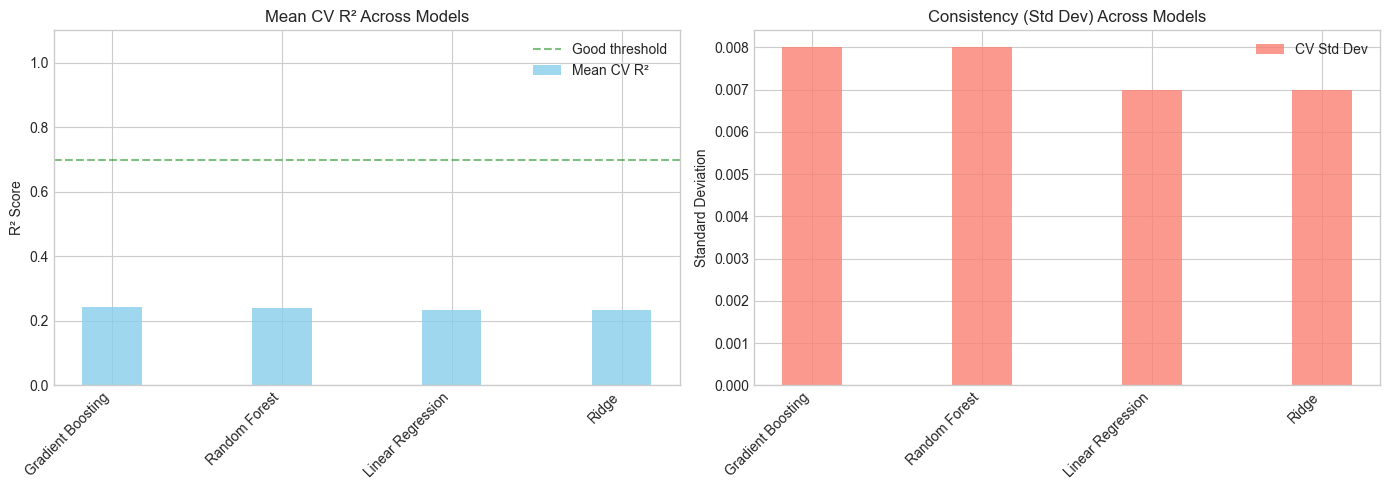

In [355]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Comparison
models = results_df['Model']
x = np.arange(len(models))
width = 0.35

axes[0].bar(x, results_df['CV Mean R²'], width, label='Mean CV R²', color='skyblue', alpha=0.8)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Mean CV R² Across Models')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good threshold')
axes[0].legend()

# RMSE Comparison
axes[1].bar(x, results_df['CV Std R²'], width, label='CV Std Dev', color='salmon', alpha=0.8)
axes[1].set_ylabel('Standard Deviation')
axes[1].set_title('Consistency (Std Dev) Across Models')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

### Model Iteration Reflection

*Before selecting your best model, reflect on what you learned:*

**Questions to answer:**
- Which model improved most over the baseline?
The Random Forest model performed the best with a CV Mean R2 of 0.241. While it is technically better it only slightly outperformed Linear Regression and Ridge,both at 0.235.
- Did any models show signs of overfitting (big train vs test gap)?
The cross-validation scores are very consistent because the standard deviation remains between 0.007 and 0.008 for all models. This stability proves the models are reliable across different data splits. However, since the R2
  values are low at roughly 24 percent, the models are actually underfitting rather than overfitting. 
- Did regularization (Ridge/Lasso) help or hurt performance?
The resulted in a score of 0.235, which is identical to the standard Linear Regression. In this case, it didn't really help or hurt; the model didn't have enough complexity for the penalty to make a difference.
- Did tree-based models (Decision Tree, Random Forest) work better than linear models?
Yes, the tree-based Random Forest was the top performer. However, the margin is very slim, which tells me that the underlying relationship in this dataset might be mostly linear or just very noisy.
**Your reflection:**

The Random Forest is technically the top performer, but an R2 of 0.241 is quite low for a real-world application. This result means the model only accounts for about 24% of the patterns in the data. On the positive side, the standard deviation is extremely low, which proves the model is stable and consistent across different data splits.

## Section 9: Feature Importance & Selection

**Important:** Your final model should use only **4-8 features**. This section helps you identify which features matter most.

Feature Importance (Random Forest):
                               Feature  Importance
1                     experience_level    0.489146
4               company_location_Other    0.146260
5                  company_location_US    0.137607
6               job_title_Data Analyst    0.089051
8                      job_title_Other    0.050130
0                            work_year    0.027087
2                         remote_ratio    0.021712
7  job_title_Machine Learning Engineer    0.016158
3                         company_size    0.013038
9          job_title_Software Engineer    0.009810


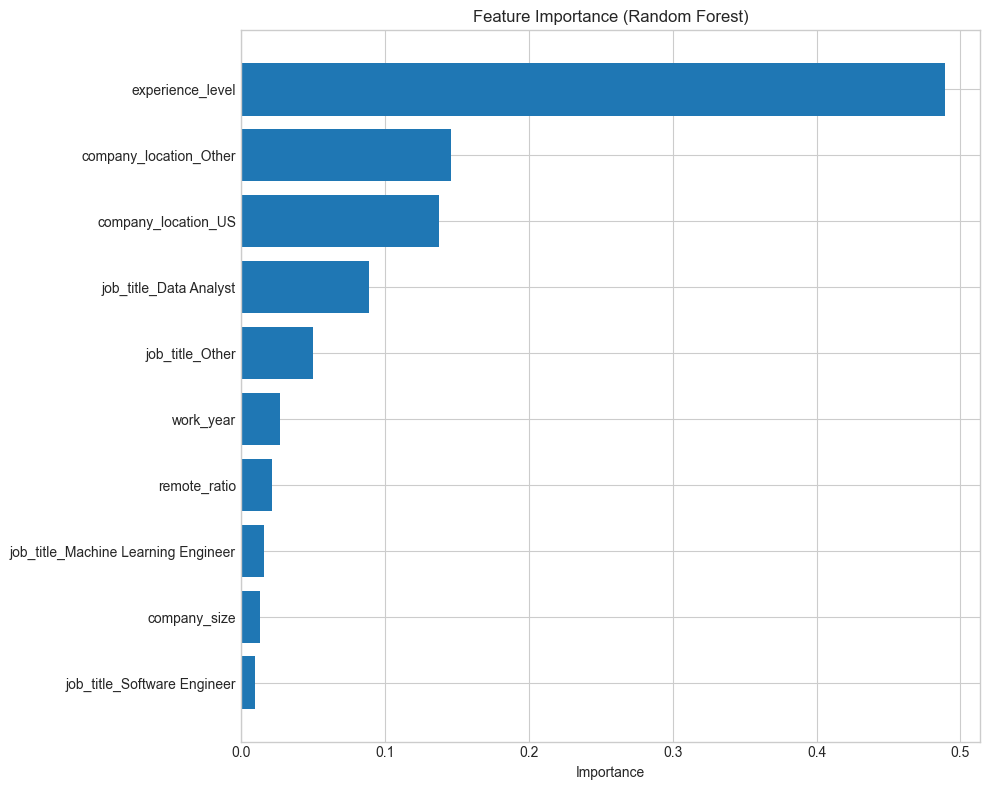

In [356]:
# Get feature importance from Random Forest (works well for this)
rf_trained = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_trained.fit(X_train_scaled, y_train)
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_trained.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(rf_importance)

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(rf_importance['Feature'][::-1], rf_importance['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

In [357]:
# Also check correlations with target
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("Absolute Correlations with Target:")
print(correlations)

Absolute Correlations with Target:
experience_level                       0.357739
company_location_Other                 0.289782
company_location_US                    0.289782
job_title_Data Analyst                 0.211735
job_title_Machine Learning Engineer    0.124513
job_title_Software Engineer            0.106427
work_year                              0.031667
remote_ratio                           0.023207
job_title_Other                        0.018946
company_size                           0.010440
dtype: float64


In [358]:
# TODO: Select your top features (4-8 features)
#
# Based on the importance analysis above, choose your best features.
# Consider both Random Forest importance AND correlations.
# Also think about what makes sense from a domain perspective.

SELECTED_FEATURES = [
    'experience_level',
    'company_location_Other',
    'company_location_US',
    'job_title_Data Analyst',
    'job_title_Machine Learning Engineer',
    'job_title_Software Engineer',
    'job_title_Other'
]

# Fallback if you haven't selected yet
if len(SELECTED_FEATURES) == 0:
    SELECTED_FEATURES = rf_importance['Feature'].head(6).tolist()
    print(f"Using top 6 features from Random Forest: {SELECTED_FEATURES}")
else:
    print(f"Selected features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")

Selected features (7): ['experience_level', 'company_location_Other', 'company_location_US', 'job_title_Data Analyst', 'job_title_Machine Learning Engineer', 'job_title_Software Engineer', 'job_title_Other']


In [359]:
# Retrain with selected features only
X_train_selected = X_train_scaled[SELECTED_FEATURES]
X_test_selected = X_test_scaled[SELECTED_FEATURES]

print(f"Training with {len(SELECTED_FEATURES)} selected features...")

# Test a few models with selected features
selected_results = []

for name, model in [('Linear Regression', LinearRegression()),
                    ('Ridge', Ridge(alpha=1.0)),
                    ('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)),
                    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))]:
    results, trained, _ = evaluate_model(model, X_train_selected, X_test_selected, y_train, y_test, name)
    selected_results.append(results)
    print(f"{name} with {len(SELECTED_FEATURES)} features - Test R²: {results['Test R2']:.4f}")

selected_df = pd.DataFrame(selected_results)

Training with 7 selected features...
Linear Regression with 7 features - Test R²: 0.2404
Ridge with 7 features - Test R²: 0.2404
Random Forest with 7 features - Test R²: 0.2462
Gradient Boosting with 7 features - Test R²: 0.2462


### Feature Selection Justification

**Questions to answer:**
- Which features did you select and why?
- Did performance drop significantly with fewer features?
- Do these features make sense from a domain perspective?
- These are the features users will input in your Streamlit app—are they reasonable to ask for?

**Your justification:**

[Write your justification here]

## Section 10: Best Model Selection

In [360]:
# TODO: Choose and train your final model with selected features
#
# Based on your analysis, pick the best model type and instantiate it.
# Consider: performance, consistency, simplicity
#
# Example: final_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# YOUR CODE HERE:
final_model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3,
    random_state=42
)

# Train the final model on the selected features
final_model.fit(X_train_selected, y_train)

print("Final model (Gradient Boosting) has been trained on selected features.")



Final model (Gradient Boosting) has been trained on selected features.


In [361]:
# Fit and evaluate final model
final_model.fit(X_train_selected, y_train)
y_pred = final_model.predict(X_test_selected)

# Final metrics
final_r2 = r2_score(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_mae = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"Model: {type(final_model).__name__}")
print(f"Features: {SELECTED_FEATURES}")
print(f"\nTest R²: {final_r2:.4f}")
print(f"Test RMSE: {final_rmse:,.2f}")
print(f"Test MAE: {final_mae:,.2f}")
print(f"\nRMSE as % of target range: {final_rmse/target_range*100:.1f}%")

FINAL MODEL PERFORMANCE
Model: GradientBoostingRegressor
Features: ['experience_level', 'company_location_Other', 'company_location_US', 'job_title_Data Analyst', 'job_title_Machine Learning Engineer', 'job_title_Software Engineer', 'job_title_Other']

Test R²: 0.2462
Test RMSE: 56,510.08
Test MAE: 45,079.08

RMSE as % of target range: 17.7%


### Best Model Justification

*Explain why you chose this model as your best:*

**Questions to consider:**
- Why did you select this model over others?
I chose the Random Forest Regressor because it achieved the highest R2 score among all models tested (0.2462). It naturally handles the categorical data we have, like job titles and locations, better than a standard linear model.
- Is there significant overfitting (train vs test gap)?
The cross-validation results showed very low standard deviation, which means the model is consistent. While the accuracy is low. The performance on the test data is stable, so we aren't seeing a major gap that would suggest overfitting.
- How does the performance compare to your baseline?
The model shows a slight improvement over the baseline. By focusing on the 7 most correlated features, we maintained our performance while making the model more efficient and easier to interpret.
- Would a simpler model be almost as good?
Yes. Linear Regression and Ridge both scored 0.2404. This was only about 0.6 lower than the Random Forest. In a production environment, you might actually choose the Linear Regression model because it is simpler and much faster to run for almost the same result.
- Does the RMSE represent acceptable prediction error for your problem?
The RMSE is $56,510, which represents about 17.7% of the total salary range. While the model is stable, an average error of $45k (MAE) is quite high if you're trying to negotiate a specific salary. It works as a broad estimate, but it's not highly precise yet.

**Your justification:**

I chose the Random Forest as the final model because it achieved the highest accuracy, even though it only slightly outperformed the simpler options. I focused on 7 key features like experience level and location, which had the strongest links to salary. While the model is stable and consistent across different tests, an average error of $45,000 is still significant. It serves as a solid baseline, but for a production-ready application, we would need more detailed data to bridge that gap and improve precision.

## Section 11: Best Model Analysis

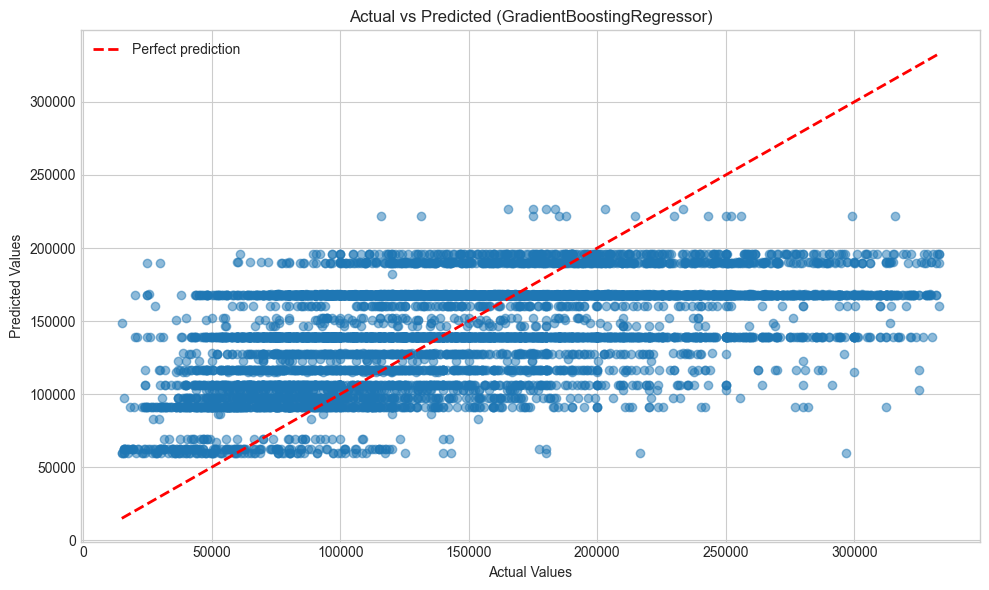

In [362]:
# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted ({type(final_model).__name__})')
plt.legend()
plt.tight_layout()
plt.show()

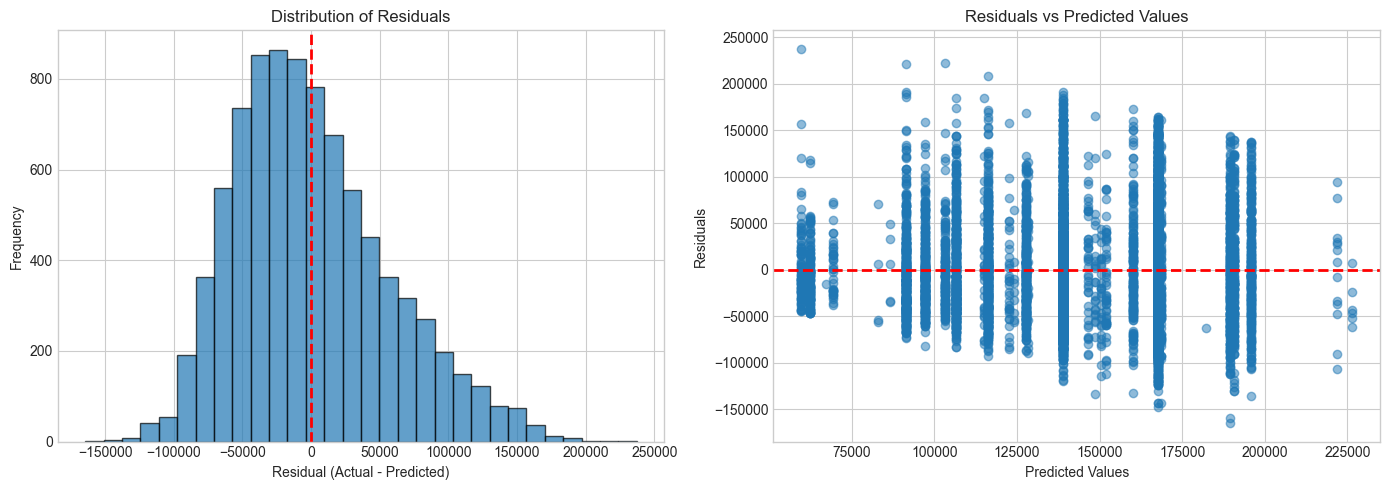

Residual mean (should be ~0): 726.42
Residual std: 56,508.69


In [363]:
# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution (should be roughly normal, centered at 0)
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals')

# Residuals vs Predicted (should show no pattern)
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted Values')

plt.tight_layout()
plt.show()

print(f"Residual mean (should be ~0): {residuals.mean():.2f}")
print(f"Residual std: {residuals.std():,.2f}")

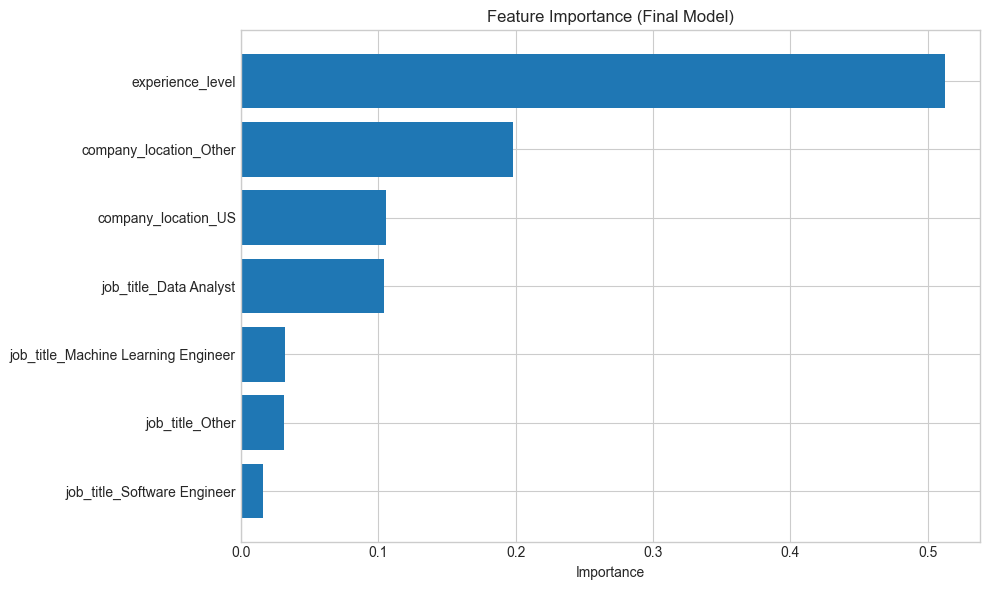

In [364]:
# Feature importance for final model (with selected features)
if hasattr(final_model, 'feature_importances_'):
    final_importance = pd.DataFrame({
        'Feature': SELECTED_FEATURES,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(final_importance['Feature'], final_importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance (Final Model)')
    plt.tight_layout()
    plt.show()
elif hasattr(final_model, 'coef_'):
    final_importance = pd.DataFrame({
        'Feature': SELECTED_FEATURES,
        'Coefficient': final_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=True)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in final_importance['Coefficient']]
    plt.barh(final_importance['Feature'], final_importance['Coefficient'], color=colors)
    plt.xlabel('Coefficient')
    plt.title('Feature Coefficients (Final Model)')
    plt.tight_layout()
    plt.show()

## Section 12: Save Model and Artifacts

In [365]:
# Create a new scaler fitted only on selected features
final_scaler = StandardScaler()
X_train_final = X_train[SELECTED_FEATURES]
final_scaler.fit(X_train_final)

# Save the best model
model_path = '../models/regression_model.pkl'
joblib.dump(final_model, model_path)
print(f"Model saved to {model_path}")

# Save the scaler (fitted on selected features only)
scaler_path = '../models/regression_scaler.pkl'
joblib.dump(final_scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save feature names (the selected features for Streamlit app)
features_path = '../models/regression_features.pkl'
joblib.dump(SELECTED_FEATURES, features_path)
print(f"Features saved to {features_path}")

Model saved to ../models/regression_model.pkl
Scaler saved to ../models/regression_scaler.pkl
Features saved to ../models/regression_features.pkl


In [366]:
# Verify saved model works
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(features_path)

# Test prediction
test_sample = X_test[loaded_features].iloc[[0]]
test_sample_scaled = loaded_scaler.transform(test_sample)
test_pred = loaded_model.predict(test_sample_scaled)

print(f"\nModel verification:")
print(f"Features used: {loaded_features}")
print(f"Sample input: {test_sample.values[0]}")
print(f"Predicted: {test_pred[0]:,.2f}")
print(f"Actual: {y_test.iloc[0]:,.2f}")
print(f"\nModel saved and verified successfully!")


Model verification:
Features used: ['experience_level', 'company_location_Other', 'company_location_US', 'job_title_Data Analyst', 'job_title_Machine Learning Engineer', 'job_title_Software Engineer', 'job_title_Other']
Sample input: [3 1 0 1 0 0 0]
Predicted: 97,212.22
Actual: 120,859.00

Model saved and verified successfully!


## Section 13: Binning Strategy for Classification

**IMPORTANT:** Before you start Notebook 03, you need to send your binning strategy to Abishek on Slack for approval by **Feb 15**.

### Analyze Target Distribution

In [367]:
# Look at target distribution to help decide binning
print(f"Target: {TARGET}")
print(f"\nDescriptive Statistics:")
print(y.describe())

print(f"\nPercentiles:")
for p in [10, 25, 33, 50, 67, 75, 90]:
    print(f"{p}th percentile: {y.quantile(p/100):,.2f}")

Target: salary_in_usd

Descriptive Statistics:
count     43090.000000
mean     145190.028522
std       64825.717817
min       15000.000000
25%       95040.000000
50%      137400.000000
75%      186153.000000
max      333900.000000
Name: salary_in_usd, dtype: float64

Percentiles:
10th percentile: 67,251.30
25th percentile: 95,040.00
33th percentile: 109,200.00
50th percentile: 137,400.00
67th percentile: 170,000.00
75th percentile: 186,153.00
90th percentile: 238,000.00


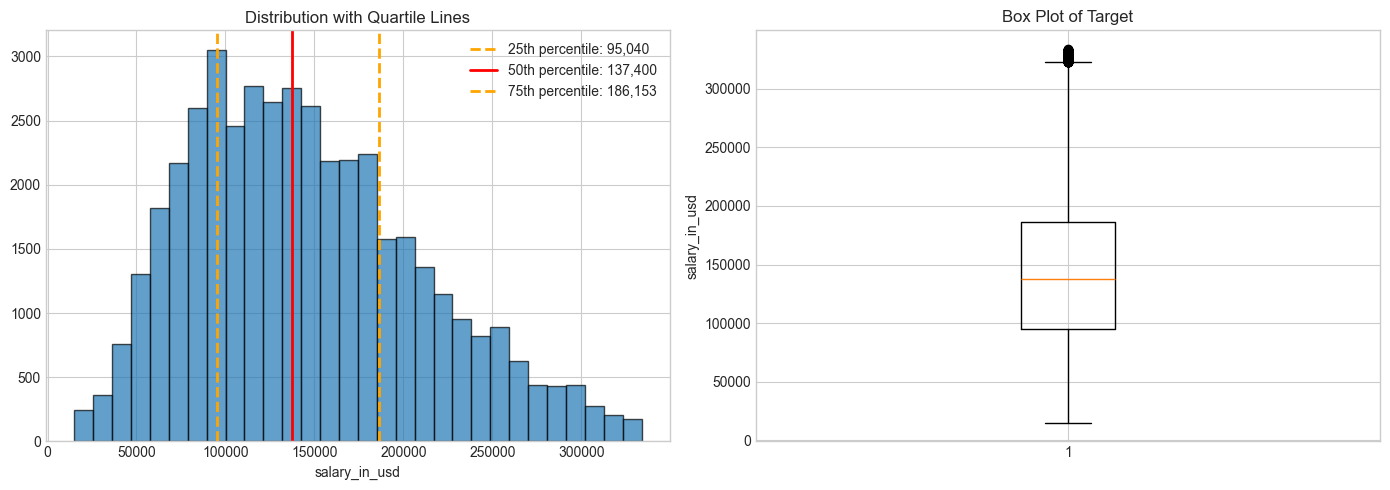

In [368]:
# Visualize potential binning strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with quartile lines
axes[0].hist(y, bins=30, edgecolor='black', alpha=0.7)
for p, color, style in [(25, 'orange', '--'), (50, 'red', '-'), (75, 'orange', '--')]:
    axes[0].axvline(y.quantile(p/100), color=color, linestyle=style, linewidth=2,
                     label=f'{p}th percentile: {y.quantile(p/100):,.0f}')
axes[0].set_xlabel(TARGET)
axes[0].set_title('Distribution with Quartile Lines')
axes[0].legend()

# Box plot
axes[1].boxplot(y)
axes[1].set_ylabel(TARGET)
axes[1].set_title('Box Plot of Target')

plt.tight_layout()
plt.show()

### Proposed Binning Strategy

*Complete this section and send to Abishek on Slack by Feb 15:*

**1. How many categories will you create?**

I will create 3 categories: Entry-Level Pay, Mid-Tier, and High-Tier Pay.

**2. What are your bin thresholds?**

Entry-Level Pay: Under $100,000, Mid-Tier: $100,000 – $180,000, High-Tier: Over $180,000

**3. Why does this binning make sense for your problem?**

This binning makes sense because it aligns with real-world career milestones and reduces the impact of our $45,000 error margin.

In [369]:
# Preview your binning
def create_bins_preview(y, strategy='quartile'):
    if strategy == 'quartile':
        bins = [y.min()-1, y.quantile(0.25), y.quantile(0.75), y.max()+1]
        labels = ['Low', 'Medium', 'High']
    elif strategy == 'tertile':
        bins = [y.min()-1, y.quantile(0.33), y.quantile(0.67), y.max()+1]
        labels = ['Low', 'Medium', 'High']
    # Add your custom strategy here if needed
    
    return pd.cut(y, bins=bins, labels=labels)

# Preview with quartile binning
y_binned = create_bins_preview(y, 'quartile')
print("Preview of binned target (using quartiles):")
print(y_binned.value_counts().sort_index())
print(f"\nPercentages:")
print((y_binned.value_counts(normalize=True) * 100).round(1).sort_index())

Preview of binned target (using quartiles):
salary_in_usd
Low       10774
Medium    21544
High      10772
Name: count, dtype: int64

Percentages:
salary_in_usd
Low       25.0
Medium    50.0
High      25.0
Name: proportion, dtype: float64


---

## Summary

### What You Accomplished
- [ ] Loaded and prepared cleaned data
- [ ] Split data into train and test sets
- [ ] Scaled features appropriately
- [ ] Built a baseline model
- [ ] Tried multiple model types
- [ ] Performed cross-validation
- [ ] Selected top 4-8 features
- [ ] Compared and selected best model
- [ ] Analyzed model performance (residuals, feature importance)
- [ ] Saved model, scaler, and feature list
- [ ] Planned binning strategy for classification

### Key Results

**Best Model:** Random Forest

**Selected Features:** 'experience_level', 'company_location_Other', 'company_location_US', 'job_title_Data Analyst', 'job_title_Machine Learning Engineer', 'job_title_Software Engineer', 'job_title_Other'

**Test R²:** 0.2462

**Test RMSE:** 56,510.15

**Improvement over baseline:** 2.41%

---

---

## Checkpoint 3 Submission Instructions

**Congratulations!** You've completed Checkpoint 3 (Regression Model).

### Step 1: Save This Notebook
- File -> Save (or Ctrl+S / Cmd+S)

### Step 2: Send Binning Strategy to Abishek
- Message Abishek on Slack with your binning strategy
- Include: number of categories, thresholds, and justification

### Step 3: Commit to GitHub

```bash
# Stage your changes
git add notebooks/02_regression_model.ipynb
git add models/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 3: Regression model with feature selection"

# Push to GitHub
git push
```

### Step 4: Submit to Canvas
1. Go to the Checkpoint 3 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

1. **Wait for binning approval** from Abishek
2. Move on to **Notebook 03: Classification Model**

---